In [1]:
import h5py
import earthcarekit as eck
from datetime import datetime
from pathlib import Path
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import matplotlib.cm as cm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
import xarray as xr
import pandas as pd
from orbits_nc import (
    save_raw_orbits, load_raw_orbits,
    iter_raw_orbits, describe_raw_nc,
)
from config import (ORBIT_FRAME, DATE_START, DATE_END,JAXA_DATA_DIR,GRID_CACHE_orbite,
    T_MIN, T_MAX, DOWNLOAD_PERIODS, HDF5_FIELDS_ORBIT_META, ORBIT_CACHE, GRID_CACHE,ALL_PARAMS)
from data_io import ( download_product, download_multi_period,
    search_product, load_orbit, load_multi_orbits, load_jaxa_orbits, merge_orbit_sources,get_t0_utc)
from processing import (prepare_single_orbit, prepare_multi_orbits, save_multi_orbits, load_multi_orbits_nc)
from plotting import (plot_multi_orbit_on_relief,plot_antarctica_relief,plot_cloud_classification,plot_temperature,plot_temperature_and_classification, plot_lat_lon,plot_distance,plot_grid_lwp,plot_grid_lwp_iwp,
    plot_ice_water_content,plot_grid_count,plot_grid_count_histogram,plot_liquid_water_content,plot_grid_results,plot_water_paths,plot_polar_scatter,plot_multi_orbit_lwp, plot_multi_orbit_iwp, plot_multi_orbit_elevation,orbites_above_threshold, plot_grid_std, plot_grid_mean)
from gridding import  GridAccumulator

### une orbite
`30 décembre 2025`

In [2]:
download_product(ORBIT_FRAME, DATE_START, DATE_END)

#======================================================================#
#                       EarthCARE Download Tool                        #
#                         earthcarekit 0.15.4                          #
#======================================================================#
# Settings
# - is_download=True
# - is_overwrite=False
# - is_unzip=True
# - is_delete=True
# - is_create_subdirs=True
# - is_log=False
# - is_debug=False
# - is_export_results=False
# - idx_selected_input=None
# - config_filepath=</home/diamankam/.config/earthcarekit/default_config.toml>
# - data_dirpath=</home/diamankam/lab/data>

+----------------------------------------------------------------------+
| STEP 1/2 - Search products                       2026-05-04 10:02:55 |
+----------------------------------------------------------------------+

*[1/1] Search request: ACM_CLP_2B, time_range=(2025-12-01T00:00:00Z,2026-02-01T00:00:00Z), frame=G, orbits=[9039]
 [1/1] Files found in collection 'JAXAL

In [3]:
ds = search_product(DATE_START, DATE_END, orbit_and_frame=ORBIT_FRAME)
display(ds)

,mission_id,agency,latency,baseline,file_type,start_sensing_time,start_processing_time,orbit_number,frame_id,orbit_and_frame,filename,filepath,hdr_filepath,start_latitude,start_longitude,end_latitude,end_longitude
0,ECA,J,X,BA,ACM_CLP_2B,2025-12-30 21:50:05,2025-12-30 23:43:04,9039,G,09039G,ECA_JXBA_ACM_CLP_2B_20251230T215005Z_20251230T...,/home/diamankam/lab/data/level2b/ACM_CLP_2B/20...,/home/diamankam/lab/data/level2b/ACM_CLP_2B/20...,NaN,NaN,NaN,NaN


In [4]:
fp = ds.filepath[0]
#fp = f"/home/diamankam/lab/data/level2b/ACM_CLP_2B/2025/12/23/BA/ECA_JXBA_ACM_CLP_2B_20251223T075003Z_20251224T093456Z_08921G/ECA_JXBA_ACM_CLP_2B_20251223T075003Z_20251224T093456Z_08921G.h5"
t0_utc = get_t0_utc(fp)
raw = load_orbit(fp)

d = prepare_single_orbit(raw, t0_utc)
d["t0_utc"] = t0_utc  

In [5]:
print(f"Fichier:{fp}")
print(f"Shapes: particle_type: {d['particle_type'].shape} " f"| temperature: {d['temperature'].shape} "f"| height: {d['HGT'].shape}")

Fichier:/home/diamankam/lab/data/level2b/ACM_CLP_2B/2025/12/30/BA/ECA_JXBA_ACM_CLP_2B_20251230T215005Z_20251230T234304Z_09039G/ECA_JXBA_ACM_CLP_2B_20251230T215005Z_20251230T234304Z_09039G.h5
Shapes: particle_type: (4669, 206) | temperature: (4669, 206) | height: (4669, 206)


`Cloud classification` : 

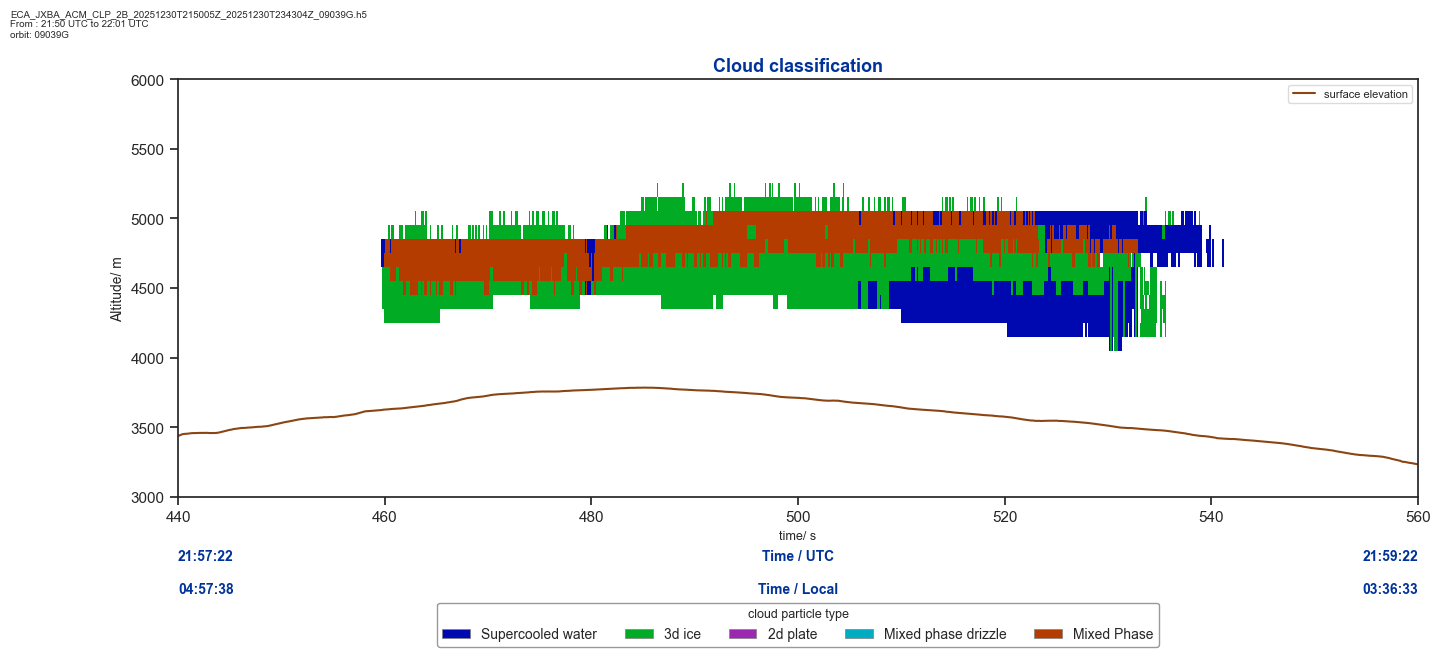

In [6]:
plot_cloud_classification(d, T_MIN, T_MAX)

`Temperature`:

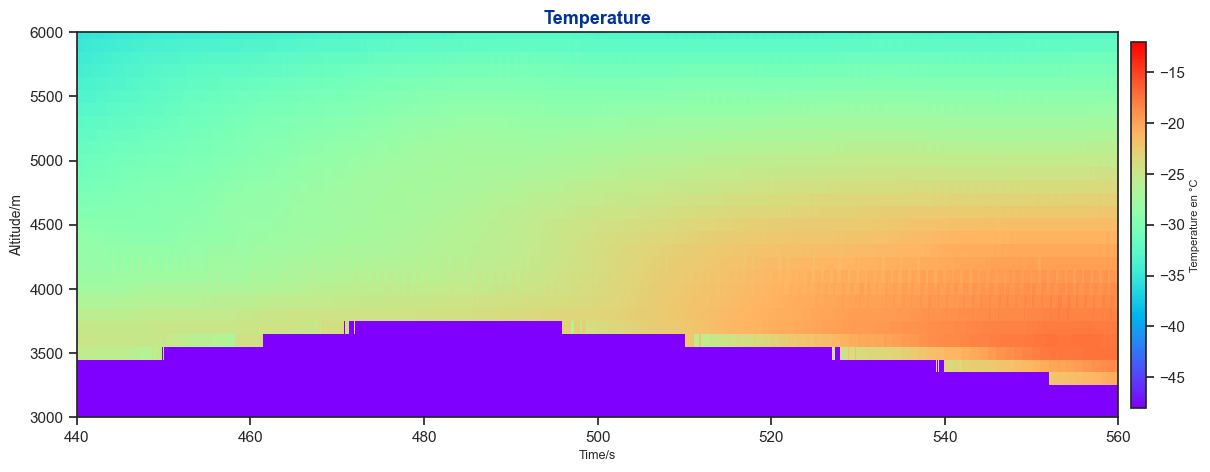

In [7]:
plot_temperature(d, T_MIN, T_MAX)

Legende à corriger 

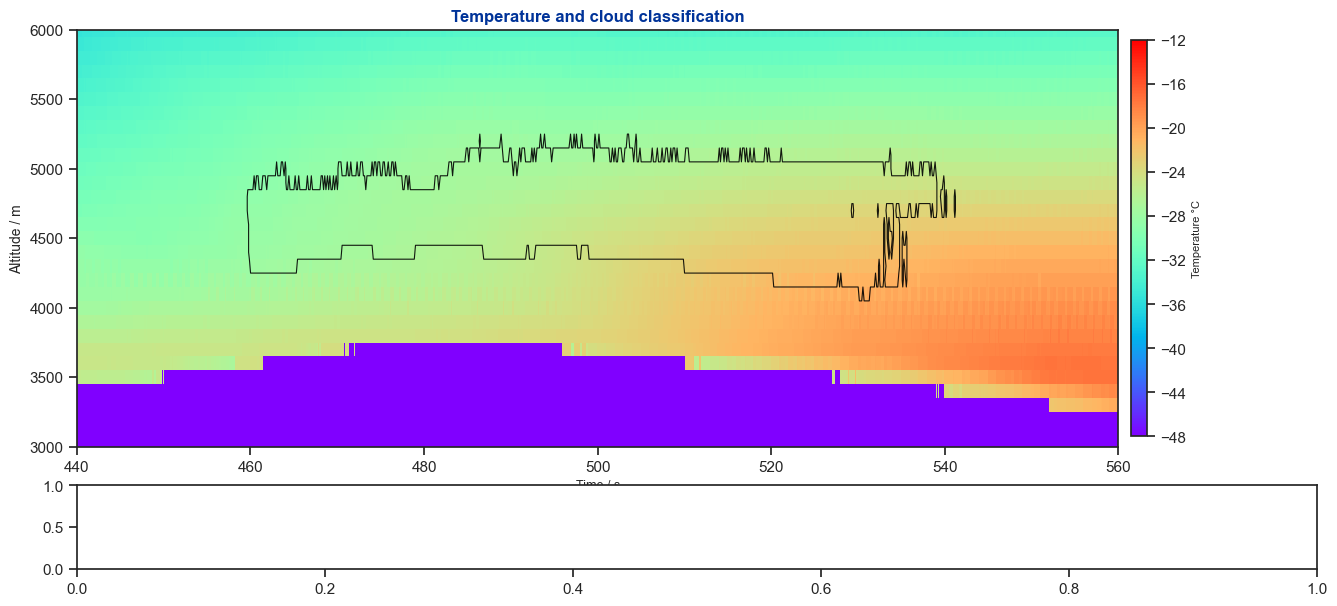

In [8]:
plot_temperature_and_classification(d, T_MIN, T_MAX)

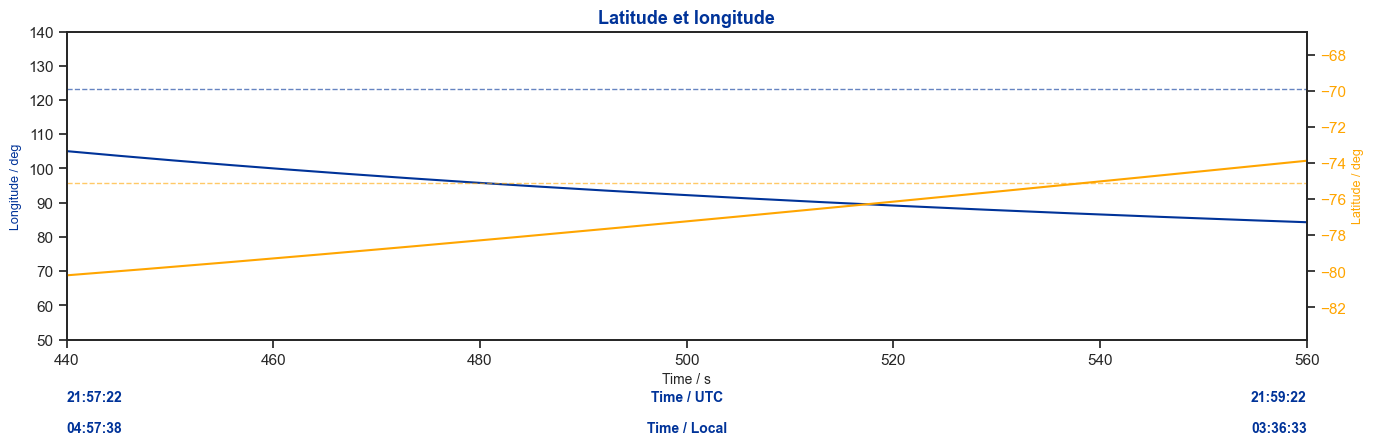

In [9]:
plot_lat_lon(d, T_MIN, T_MAX)

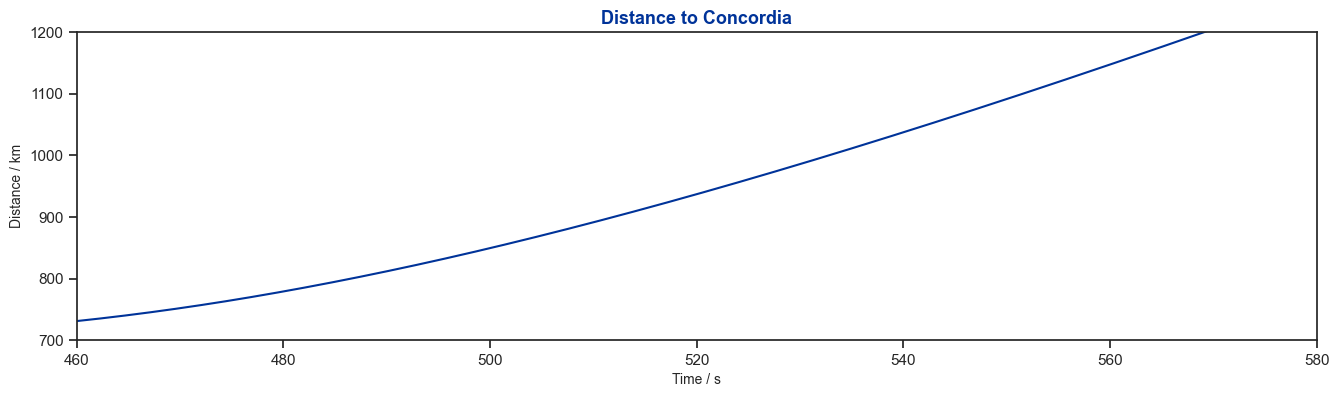

In [10]:
plot_distance(d)

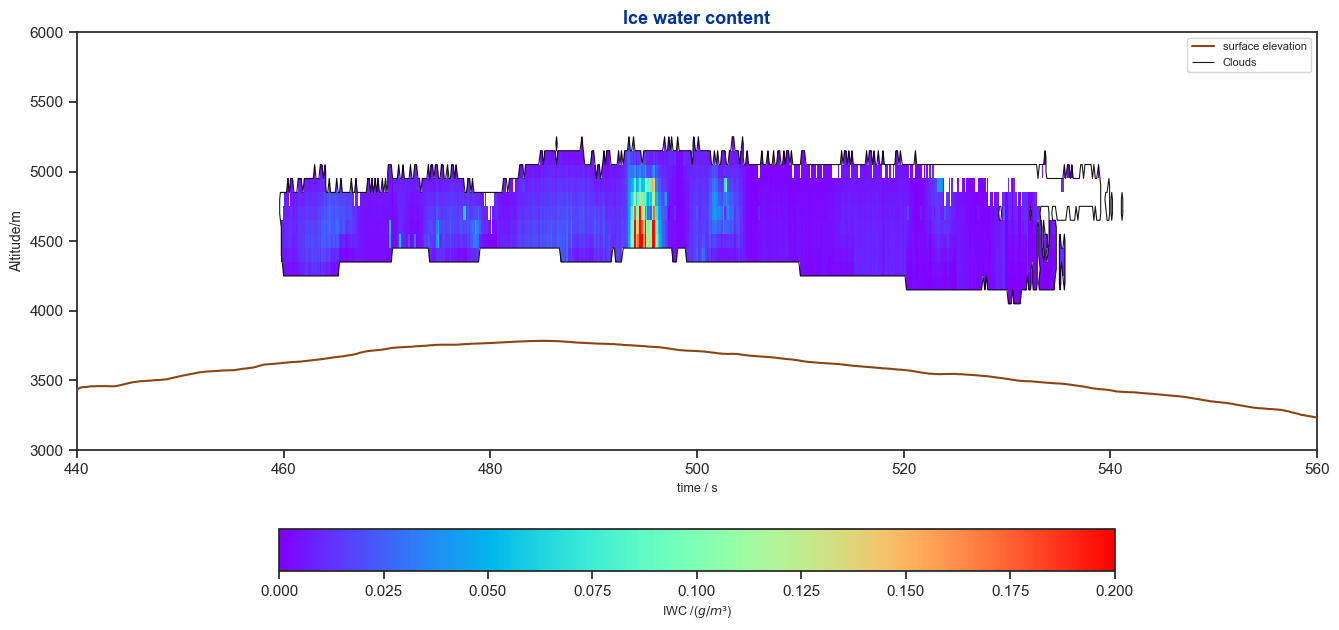

In [11]:
plot_ice_water_content(d, T_MIN, T_MAX)

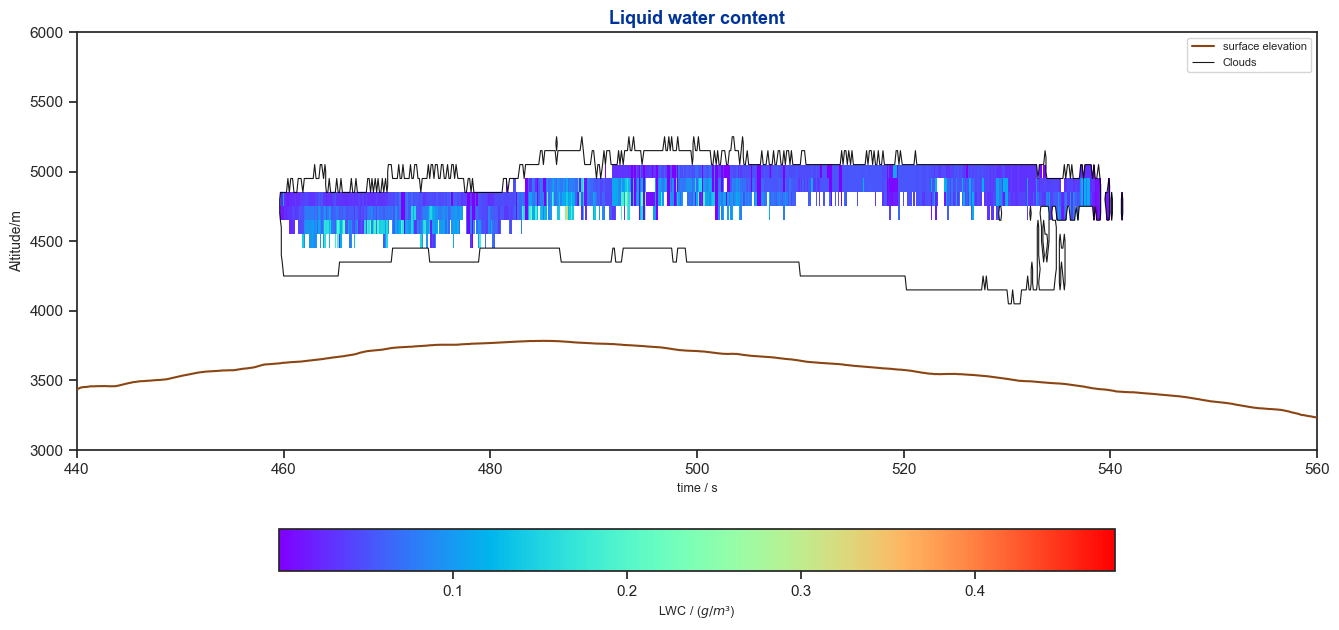

In [12]:
plot_liquid_water_content(d, T_MIN, T_MAX)

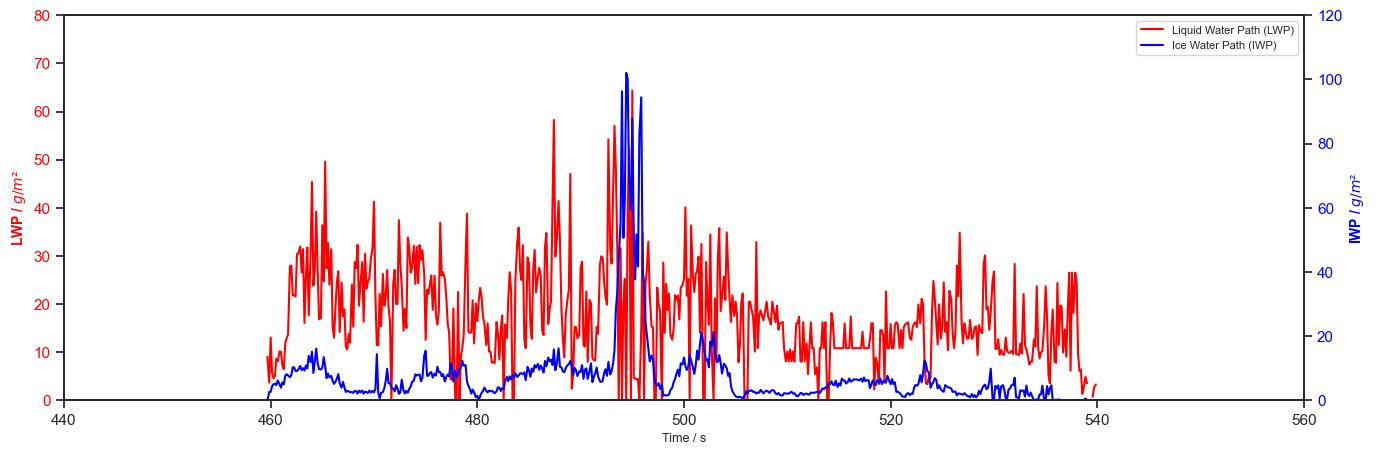

In [13]:
plot_water_paths(d, T_MIN, T_MAX)

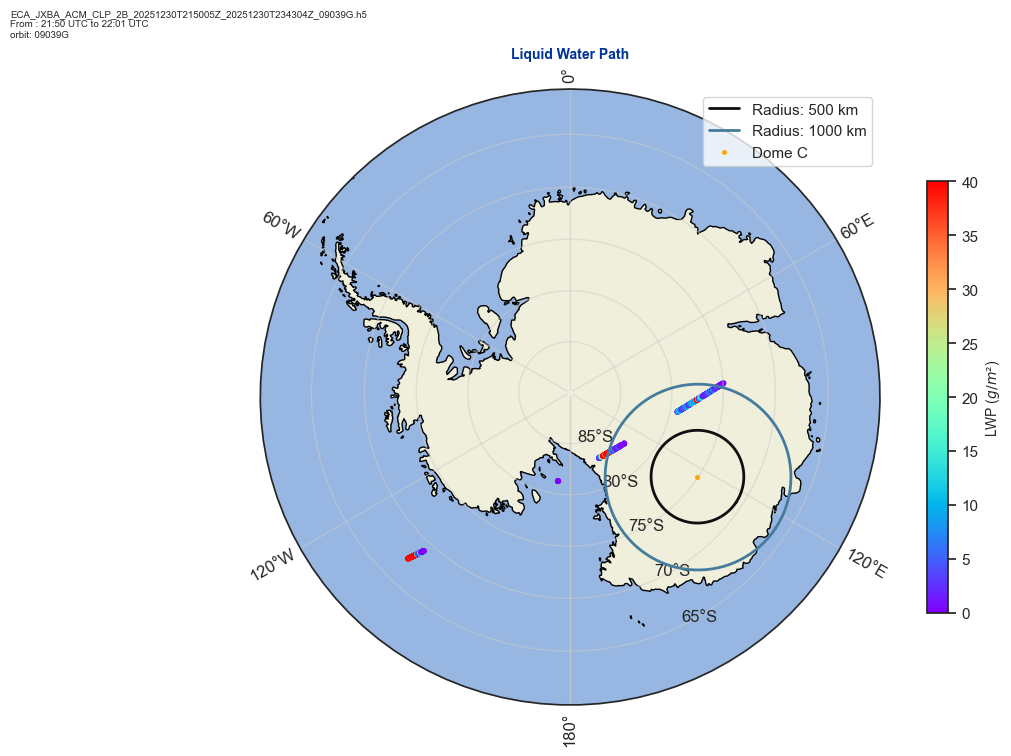

In [14]:
plot_polar_scatter( d["lon"], d["lat"], d["iwp_plot"],title="Liquid Water Path", cbar_label="LWP ($g/m²$)",
        t_utc_start=d["t_utc_start"], t_utc_end=d["t_utc_end"],
        orbit_id=ORBIT_FRAME, vmin=0, vmax=40,gridlines_labels=True)

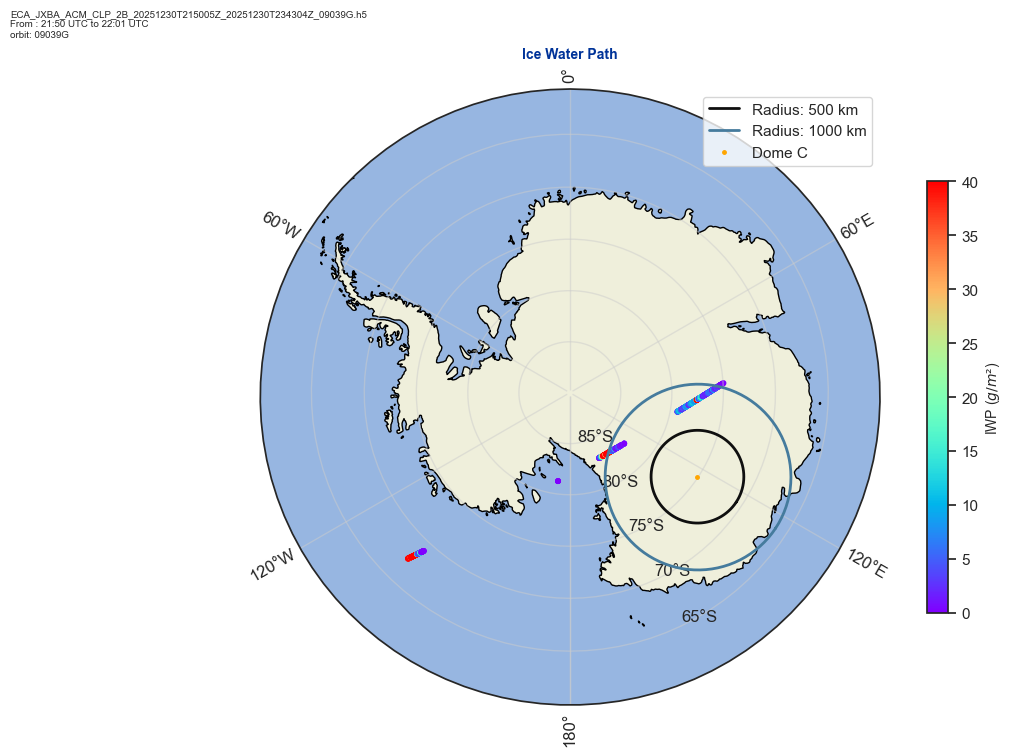

In [ ]:
plot_polar_scatter(d["lon"], d["lat"], d["iwp_plot"],title="Ice Water Path", cbar_label="IWP ($g/m²$)",
        t_utc_start=d["t_utc_start"], t_utc_end=d["t_utc_end"],
        orbit_id=ORBIT_FRAME, vmin=0, vmax=40,gridlines_labels=True)

Mettre les figure d'une seule orbite aprés

### 1 mois de données 
du `01 décembre au 31 décembre 2025`

In [8]:
download_multi_period(DOWNLOAD_PERIODS, frame_id="F")

#======================================================================#
#                       EarthCARE Download Tool                        #
#                         earthcarekit 0.15.4                          #
#======================================================================#
# Settings
# - is_download=True
# - is_overwrite=False
# - is_unzip=True
# - is_delete=True
# - is_create_subdirs=True
# - is_log=False
# - is_debug=False
# - is_export_results=False
# - idx_selected_input=None
# - config_filepath=<C:\Users\Dell\.config\earthcarekit\default_config.toml>
# - data_dirpath=<C:/Users/Dell/Desktop/project_lab/earthcare_code/data>

+----------------------------------------------------------------------+
| STEP 1/2 - Search products                       2026-05-09 18:00:16 |
+----------------------------------------------------------------------+

*[1/1] Search request: ACM_CLP_2B, time_range=(2025-12-01T00:00:00,2026-02-01T00:00:00), frame=F
 [1/1] Files found in collect

In [2]:
ds_multi = search_product(DATE_START, DATE_END, all_frames=True)

display(ds_multi)

[search] Frame F : 70 fichier(s)
[search] Frame G : 70 fichier(s)
[search] Frame H : 70 fichier(s)
[search] Total : 210 fichier(s) (frames F+G+H)


['C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T105044Z_20251205T151048Z_08643F\\ECA_JXBA_ACM_CLP_2B_20251205T105044Z_20251205T151048Z_08643F.h5',
 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T122317Z_20251205T150136Z_08644F\\ECA_JXBA_ACM_CLP_2B_20251205T122317Z_20251205T150136Z_08644F.h5',
 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T135550Z_20251205T155116Z_08645F\\ECA_JXBA_ACM_CLP_2B_20251205T135550Z_20251205T155116Z_08645F.h5',
 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T152822Z_20251205T174320Z_08646F\\ECA_JXBA_ACM_CLP_2B_20251205T152822Z_20251205T174320Z_08646F.h5',
 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_

In [4]:
print(ds_multi)

['C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T105044Z_20251205T151048Z_08643F\\ECA_JXBA_ACM_CLP_2B_20251205T105044Z_20251205T151048Z_08643F.h5', 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T122317Z_20251205T150136Z_08644F\\ECA_JXBA_ACM_CLP_2B_20251205T122317Z_20251205T150136Z_08644F.h5', 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T135550Z_20251205T155116Z_08645F\\ECA_JXBA_ACM_CLP_2B_20251205T135550Z_20251205T155116Z_08645F.h5', 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\2025\\12\\05\\BA\\ECA_JXBA_ACM_CLP_2B_20251205T152822Z_20251205T174320Z_08646F\\ECA_JXBA_ACM_CLP_2B_20251205T152822Z_20251205T174320Z_08646F.h5', 'C:\\Users\\Dell\\Desktop\\project_lab\\earthcare_code\\data\\level2b\\ACM_CLP_2B\\

In [3]:
esa_raw   = load_multi_orbits(ds_multi,
                                  extra_fields=HDF5_FIELDS_ORBIT_META)

[load] [8643] — ECA_JXBA_ACM_CLP_2B_20251205T105044Z_20251205T151048Z_08643F.h5
[load] [8644] — ECA_JXBA_ACM_CLP_2B_20251205T122317Z_20251205T150136Z_08644F.h5
[load] [8645] — ECA_JXBA_ACM_CLP_2B_20251205T135550Z_20251205T155116Z_08645F.h5
[load] [8646] — ECA_JXBA_ACM_CLP_2B_20251205T152822Z_20251205T174320Z_08646F.h5
[load] [8647] — ECA_JXBA_ACM_CLP_2B_20251205T170055Z_20251205T203316Z_08647F.h5
[load] [8648] — ECA_JXBA_ACM_CLP_2B_20251205T183327Z_20251205T204333Z_08648F.h5
[load] [8649] — ECA_JXBA_ACM_CLP_2B_20251205T200600Z_20251205T235659Z_08649F.h5
[load] [8650] — ECA_JXBA_ACM_CLP_2B_20251205T213833Z_20251205T234056Z_08650F.h5
[load] [8651] — ECA_JXBA_ACM_CLP_2B_20251205T231106Z_20251206T012456Z_08651F.h5
[load] [8652] — ECA_JXBA_ACM_CLP_2B_20251206T004338Z_20251208T162441Z_08652F.h5
[load] [8653] — ECA_JXBA_ACM_CLP_2B_20251206T021611Z_20251206T041807Z_08653F.h5
[load] [8654] — ECA_JXBA_ACM_CLP_2B_20251206T034843Z_20251206T072322Z_08654F.h5
[load] [8655] — ECA_JXBA_ACM_CLP_2B_2025

In [4]:
orbites         = prepare_multi_orbits(esa_raw)
n_orbites_label = []

In [2]:
ORBIT_CACHE = "./data/cache/orbite_cache-1.nc"


In [6]:
def run_raw_nc(force_rebuild: bool = False) -> str:
    """Charge tous les HDF5 et les sauvegarde dans orbites_raw.nc.
 
    Ce fichier sert de source unique pour le gridding et les analyses.
    Il n'est construit qu'une seule fois.
 
    Returns
    -------
    str  chemin du fichier .nc cree
    """
    from pathlib import Path
 
    if not force_rebuild and Path(ORBIT_CACHE).exists():
        print(f"[raw_nc] Cache existant : {ORBIT_CACHE}")
        describe_raw_nc(ORBIT_CACHE)
        return ORBIT_CACHE
 
    print("[raw_nc] Construction depuis les HDF5...")
 
    # Charger toutes les frames F, G, H (ESA + JAXA)
    #filepaths = search_product(DATE_START, DATE_END, all_frames=True)
    extra     = HDF5_FIELDS_ORBIT_META.copy()
    
    # esa_raw  = load_multi_orbits(filepaths, extra_fields=extra)
    # jaxa_raw = load_jaxa_orbits(JAXA_DATA_DIR, extra_fields=extra)
    # all_raw  = merge_orbit_sources(esa_raw, jaxa_raw, sort_by="start_time")
 
    save_raw_orbits(esa_raw, ORBIT_CACHE)
    describe_raw_nc(ORBIT_CACHE)
    return ORBIT_CACHE

In [5]:
run_raw_nc() 

NameError: name 'run_raw_nc' is not defined

In [ ]:
def run_grid(force_rebuild: bool = False) -> GridAccumulator:
    """Accumule toutes les orbites jour par jour sur la grille lat/lon.
 
    Si le cache GRID_CACHE existe et que force_rebuild=False,
    la grille est rechargee instantanement depuis le .nc.
 
    Parameters
    ----------
    force_rebuild : bool, default False
 
    Returns
    -------
    GridAccumulator
    """
    from pathlib import Path
 
    cache_path = Path(GRID_CACHE)
 
    if not force_rebuild and cache_path.exists():
        print(f"[grid] Cache trouvé ({cache_path})")
        return GridAccumulator.load(str(cache_path))
 
    print("[grid] Construction de la grille depuis les orbites brutes...")
    cache_path.parent.mkdir(parents=True, exist_ok=True)
 
    #download_multi_period(DOWNLOAD_PERIODS)
    # Utiliser orbites_raw.nc comme source — pas de re-lecture HDF5
    from pathlib import Path as _Path
    if not _Path(ORBIT_CACHE).exists():
        print("[grid] orbites_raw.nc absent — lancement de run_raw_nc()")
        run_raw_nc()
 
    grid  = GridAccumulator(dlat=1.0, dlon=10.0)
    total = sum(1 for _ in iter_raw_orbits(ORBIT_CACHE))   # compter
    for i, orb in enumerate(iter_raw_orbits(ORBIT_CACHE), 1):
        grid.accumulate(orb)
        if i % 10 == 0 or i == total:
            print(f"  {i}/{total} orbites accumulées...")
            try:
                grid.save(str(cache_path))
            except Exception as e:
                print(f"  [grid] Sauvegarde impossible : {e}")
 
    print(f"[grid] Terminé — {grid}")
    return grid

In [ ]:
run_grid(force_rebuild=True)

[grid] Construction de la grille depuis les orbites brutes...
2025-12-05


c:\Users\Dell\Desktop\project_lab\earthcare_code\gridding.py:79: RuntimeWarning: Mean of empty slice
  result = np.nanmean(arr2d, axis=1)


2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
  10/210 orbites accumulées...
[grid] Sauvegardé → data\cache\grid_cache.nc
       1 jours | 10 orbites | 1.2 MB
       Période : 2025-12-05 -> 2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
  20/210 orbites accumulées...
[grid] Sauvegardé → data\cache\grid_cache.nc
       1 jours | 20 orbites | 1.2 MB
       Période : 2025-12-05 -> 2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-05
2025-12-06
2025-12-06
2025-12-06
  30/210 orbites accumulées...
[grid] Sauvegardé → data\cache\grid_cache.nc
       2 jours | 30 orbites | 2.3 MB
       Période : 2025-12-05 -> 2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
2025-12-06
  40/210 orbites accumulées...
[grid] Sauvegardé → data\cache\grid_cache.nc
       2 jours | 40 orbites | 

GridAccumulator(dlat=1.0°, dlon=10.0°, 181×37 cells, 5 jours, 210 orbites, 2025-12-05 -> 2025-12-09)

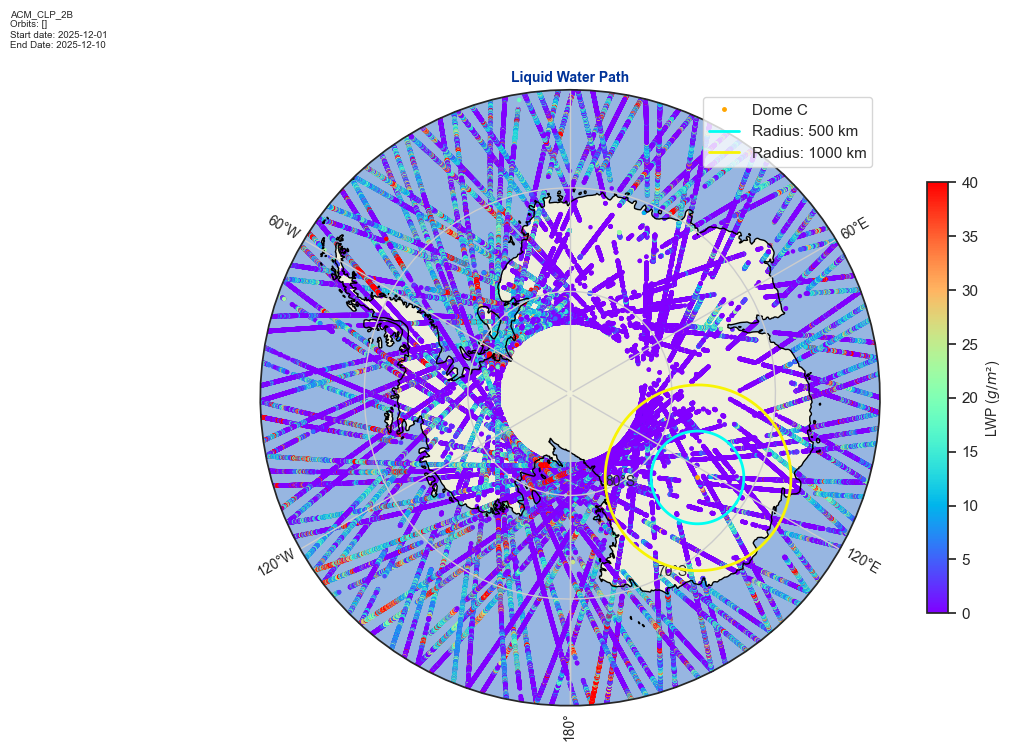

In [7]:
plot_multi_orbit_lwp(orbites, n_orbites_label)

In [3]:
raw_orbits = load_multi_orbits(ds_multi.filepath, extra_fields=HDF5_FIELDS_ORBIT_META)

Orbite [8643] chargée
Orbite [8644] chargée
Orbite [8645] chargée
Orbite [8646] chargée
Orbite [8647] chargée
Orbite [8648] chargée
Orbite [8649] chargée
Orbite [8650] chargée
Orbite [8651] chargée
Orbite [8652] chargée
Orbite [8653] chargée
Orbite [8654] chargée
Orbite [8655] chargée
Orbite [8656] chargée
Orbite [8657] chargée
Orbite [8658] chargée
Orbite [8659] chargée
Orbite [8660] chargée
Orbite [8661] chargée
Orbite [8662] chargée
Orbite [8663] chargée
Orbite [8664] chargée
Orbite [8665] chargée
Orbite [8666] chargée
Orbite [8667] chargée
Orbite [8668] chargée
Orbite [8669] chargée
Orbite [8670] chargée
Orbite [8671] chargée
Orbite [8672] chargée
Orbite [8673] chargée
Orbite [8674] chargée
Orbite [8675] chargée
Orbite [8676] chargée
Orbite [8677] chargée
Orbite [8678] chargée
Orbite [8679] chargée
Orbite [8680] chargée
Orbite [8681] chargée
Orbite [8682] chargée
Orbite [8683] chargée
Orbite [8684] chargée
Orbite [8685] chargée
Orbite [8686] chargée
Orbite [8687] chargée
Orbite [86

L'outil EarthcareKit ne prend pas en charge les produits `ACM_CLP_2BS`. Il faut donc les telecharger sur `https://gportal.jaxa.jp/gpr/`, puis les combiner avec les données de l'ESA.

In [4]:
jaxa_raw = load_jaxa_orbits(JAXA_DATA_DIR, extra_fields=HDF5_FIELDS_ORBIT_META)

77 fichier(s) trouvé(s) dans ./data/jaxa
Orbite [8574] chargée
Orbite [8575] chargée
Orbite [8576] chargée
Orbite [8577] chargée
Orbite [8578] chargée
Orbite [8579] chargée
Orbite [8580] chargée
Orbite [8581] chargée
Orbite [8582] chargée
Orbite [8583] chargée
Orbite [8584] chargée
Orbite [8585] chargée
Orbite [8586] chargée
Orbite [8587] chargée
Orbite [8588] chargée
Orbite [8589] chargée
Orbite [8590] chargée
Orbite [8591] chargée
Orbite [8592] chargée
Orbite [8593] chargée
Orbite [8594] chargée
Orbite [8595] chargée
Orbite [8596] chargée
Orbite [8597] chargée
Orbite [8598] chargée
Orbite [8599] chargée
Orbite [8600] chargée
Orbite [8602] chargée
Orbite [8603] chargée
Orbite [8604] chargée
Orbite [8605] chargée
Orbite [8606] chargée
Orbite [8607] chargée
Orbite [8608] chargée
Orbite [8609] chargée
Orbite [8610] chargée
Orbite [8611] chargée
Orbite [8612] chargée
Orbite [8613] chargée
Orbite [8614] chargée
Orbite [8615] chargée
Orbite [8616] chargée
Orbite [8617] chargée
Orbite [8618]

In [21]:
jaxa_raw[0]

{'particle_type': array([[  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127],
        ...,
        [  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127]],
       shape=(4668, 206), dtype=int8),
 'temperature': array([[-9999.     ,   231.60568,   231.65038, ..., -9999.     ,
         -9999.     , -9999.     ],
        [-9999.     ,   231.60663,   231.65111, ..., -9999.     ,
         -9999.     , -9999.     ],
        [-9999.     ,   231.60898,   231.6533 , ..., -9999.     ,
         -9999.     , -9999.     ],
        ...,
        [  231.84596,   231.8206 ,   231.79523, ..., -9999.     ,
         -9999.     , -9999.     ],
        [  231.8512 ,   231.8265 ,   231.80183, ..., -9999.     ,
         -9999.     , -9999.     ],
        [  231.85252,   231.82846,   231.80441, ..., -9999.     ,
         -9999.     

In [5]:
all_raw = merge_orbit_sources(raw_orbits, jaxa_raw, sort_by="start_time")

845 orbites ESA  +  77 orbites JAXA 922 au total, triées par 'start_time'.


In [8]:
all_raw[0]

{'particle_type': array([[  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127],
        ...,
        [  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127],
        [  -9,   -9,   -9, ..., -127, -127, -127]],
       shape=(4668, 206), dtype=int8),
 'temperature': array([[-9999.     ,   231.60568,   231.65038, ..., -9999.     ,
         -9999.     , -9999.     ],
        [-9999.     ,   231.60663,   231.65111, ..., -9999.     ,
         -9999.     , -9999.     ],
        [-9999.     ,   231.60898,   231.6533 , ..., -9999.     ,
         -9999.     , -9999.     ],
        ...,
        [  231.84596,   231.8206 ,   231.79523, ..., -9999.     ,
         -9999.     , -9999.     ],
        [  231.8512 ,   231.8265 ,   231.80183, ..., -9999.     ,
         -9999.     , -9999.     ],
        [  231.85252,   231.82846,   231.80441, ..., -9999.     ,
         -9999.     

In [6]:
orbites = prepare_multi_orbits(all_raw)

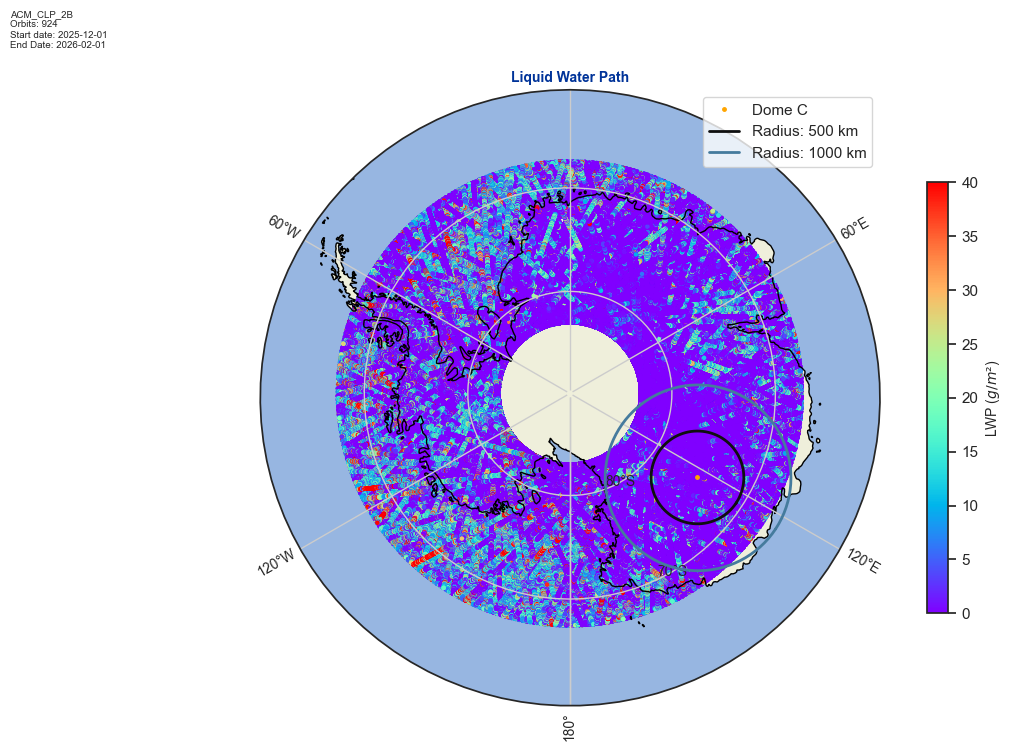

In [25]:
plot_multi_orbit_lwp(orbites, len(orbites))

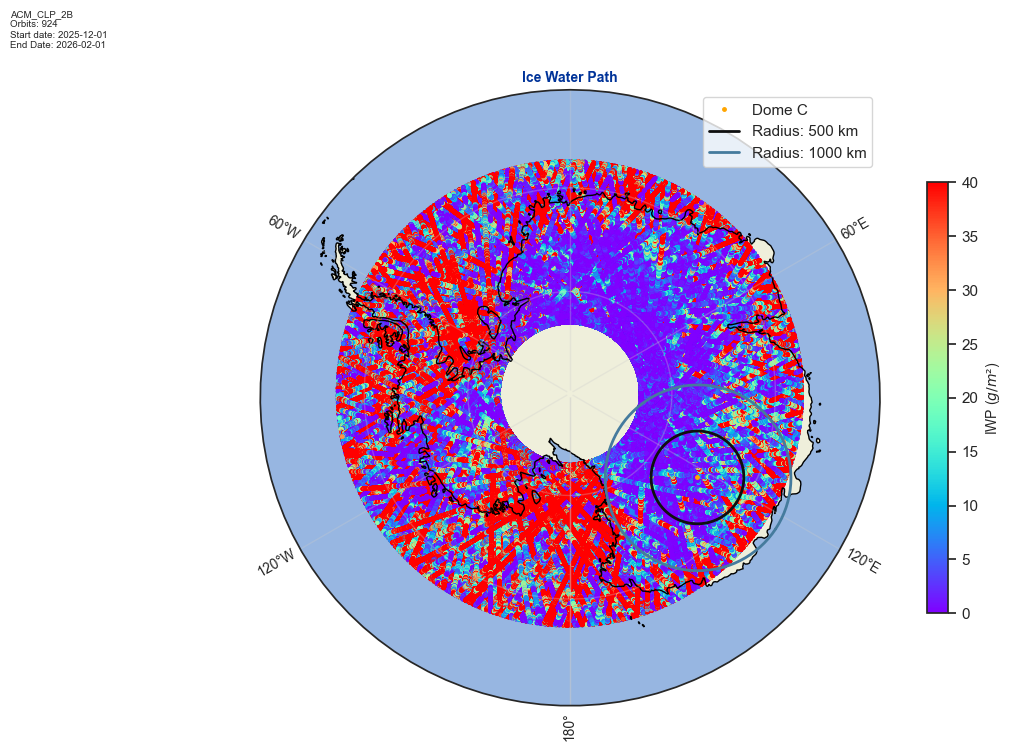

In [26]:
plot_multi_orbit_iwp(orbites, len(orbites))

In [7]:
save_multi_orbits(orbites, ORBIT_CACHE)

/home/diamankam/lab/processing.py:147: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'point' ('point',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(datasets, dim="orbite")


{'orbit_id': "[9538]G_('2026-01-31T23:30:00',)", 'nom_orbite': '[9538]', 'start_day': '2026-01-31T23:30:00', 'lat': array([-67.5043531 , -67.51551409, -67.5238239 , ..., -67.51526926,
       -67.50695684, -67.4986443 ], shape=(4669,)), 'lon': array([-160.67418603, -160.68474594, -160.69261362, ...,   51.02451581,
         51.01664006,   51.00876957], shape=(4669,)), 'lwp': array([0., 0., 0., ..., 0., 0., 0.], shape=(4669,), dtype=float32), 'iwp': array([272.99197, 214.4138 , 190.08757, ..., 883.85516, 821.7096 ,
       799.332  ], shape=(4669,), dtype=float32)}
Sauvegarde dans ./data/cache/orbite_cache.nc
922 orbites | 377023 KB
Periode : du 2025-12-01T00:36:54 au 2026-01-31T23:30:00


In [4]:
data = load_multi_orbits_nc(ORBIT_CACHE)

orbites Charge : ./data/cache/orbite_cache.nc  (922 orbites)
Periode : du  2025-12-01T00:36:54 au 2026-01-31T23:30:00


In [12]:
thresold = orbites_above_threshold(data, param="lwp", threshold=1000)

LWP > 1000 g/m2
  0/444 orbite concernee :
Aucune orbite ne depasse ce seuil.


In [6]:
df = pd.DataFrame({orb["orbit_id"]: pd.Series(orb["lwp"]) for orb in data})

In [7]:
df

,"[8574]G_('2025-12-01T00:36:54',)","[8575]G_('2025-12-01T02:09:26',)","[8576]G_('2025-12-01T03:41:58',)","[8577]G_('2025-12-01T05:14:31',)","[8578]G_('2025-12-01T06:47:03',)","[8579]G_('2025-12-01T08:19:36',)","[8580]G_('2025-12-01T09:52:08',)","[8581]G_('2025-12-01T11:24:41',)","[8582]G_('2025-12-01T12:57:13',)","[8583]G_('2025-12-01T14:29:46',)",...,"[9529]G_('2026-01-31T09:37:04',)","[9530]G_('2026-01-31T11:09:37',)","[9531]G_('2026-01-31T12:42:10',)","[9532]G_('2026-01-31T14:14:43',)","[9533]G_('2026-01-31T15:47:15',)","[9534]G_('2026-01-31T17:19:48',)","[9535]G_('2026-01-31T18:52:21',)","[9536]G_('2026-01-31T20:24:54',)","[9537]G_('2026-01-31T21:57:27',)","[9538]G_('2026-01-31T23:30:00',)"
0,36.064743,9.206415,9.510699,NaN,NaN,NaN,NaN,NaN,10.560225,15.008250,...,0.0,24.539757,4.157366,0.0,0.0,0.00000,11.563275,4.420120,70.213135,0.000000
1,0.445140,163.465240,14.935325,NaN,NaN,NaN,NaN,0.0,10.575720,26.867409,...,0.0,8.331919,21.813135,0.0,0.0,0.00000,15.575152,22.430288,126.117485,0.000000
2,30.731487,277.184723,8.350476,NaN,NaN,NaN,NaN,0.0,6.697726,31.276684,...,0.0,8.084374,8.564610,0.0,0.0,0.00000,22.328970,22.329992,122.021477,0.000000
3,33.364239,215.964813,10.666130,0.0,NaN,NaN,NaN,0.0,6.746854,8.115338,...,0.0,9.264060,17.072197,0.0,0.0,0.00000,10.934576,11.181112,113.683281,0.416693
4,32.415245,89.270004,11.042810,NaN,NaN,NaN,NaN,NaN,10.202082,7.750089,...,0.0,8.475330,17.766985,0.0,0.0,13.58314,14.473102,44.059448,54.072243,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df.describe()

/home/diamankam/lab/.env/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/diamankam/lab/.env/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,"[8574]G_('2025-12-01T00:36:54',)","[8575]G_('2025-12-01T02:09:26',)","[8576]G_('2025-12-01T03:41:58',)","[8577]G_('2025-12-01T05:14:31',)","[8578]G_('2025-12-01T06:47:03',)","[8579]G_('2025-12-01T08:19:36',)","[8580]G_('2025-12-01T09:52:08',)","[8581]G_('2025-12-01T11:24:41',)","[8582]G_('2025-12-01T12:57:13',)","[8583]G_('2025-12-01T14:29:46',)",...,"[9529]G_('2026-01-31T09:37:04',)","[9530]G_('2026-01-31T11:09:37',)","[9531]G_('2026-01-31T12:42:10',)","[9532]G_('2026-01-31T14:14:43',)","[9533]G_('2026-01-31T15:47:15',)","[9534]G_('2026-01-31T17:19:48',)","[9535]G_('2026-01-31T18:52:21',)","[9536]G_('2026-01-31T20:24:54',)","[9537]G_('2026-01-31T21:57:27',)","[9538]G_('2026-01-31T23:30:00',)"
count,2026.000000,2731.000000,2131.000000,1276.000000,1940.000000,1806.000000,1922.000000,1991.000000,3717.000000,3599.000000,...,1807.000000,2362.000000,2889.000000,3931.000000,3492.000000,3202.000000,3267.000000,3262.000000,3717.000000,3376.000000
mean,8.460204,9.477253,6.412792,22.132492,26.706104,12.045399,8.004487,8.652384,9.827635,17.467464,...,4.243023,12.129864,10.358160,14.333945,9.591369,7.105230,8.216481,16.257889,12.906661,9.342255
std,22.146839,24.205496,10.652242,48.033607,48.239372,30.082899,14.120373,14.688877,16.606569,26.464451,...,7.558788,25.653225,13.014239,25.919188,22.841698,22.707712,20.658136,43.549061,31.179779,17.253691
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.019147,0.000000,0.000000,0.000000,0.000000,0.000000,1.463952,...,0.000000,0.000000,0.016585,0.021115,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.027052,0.011196,10.420410,9.081773,0.000298,2.321269,0.022119,2.186226,9.351288,...,0.000000,0.024412,7.541970,8.927460,0.020082,0.000000,0.000000,0.049129,0.000000,0.073951
75%,8.114314,11.683793,11.038258,21.269812,22.359711,11.843071,11.731970,13.527228,14.451935,19.973297,...,6.475639,14.624765,16.408991,17.143431,11.629329,5.424248,10.808320,14.571726,10.826380,13.019952
max,286.520050,277.390717,95.008636,419.748413,401.145264,340.457275,202.351776,179.727753,244.377045,367.766693,...,61.730480,415.308472,204.900452,385.179199,320.989349,338.094025,320.296661,438.048431,378.777283,252.771103


In [13]:
outliers = df.columns[(df>100).any()].tolist()
print(len(outliers))

NameError: name 'df' is not defined

In [9]:
counts = (df > 100).sum().sort_values(ascending=False)
print(counts.head(20))

[8921]G_('2025-12-23T07:50:00',)    4668
[9098]G_('2026-01-03T16:50:21',)    4668
[9113]G_('2026-01-04T15:58:29',)     219
[8849]G_('2025-12-18T16:46:50',)     183
[8578]G_('2025-12-01T06:47:03',)     183
[9252]G_('2026-01-13T14:22:22',)     176
[8817]G_('2025-12-16T15:25:18',)     157
[9267]G_('2026-01-14T13:30:36',)     156
[8692]G_('2025-12-08T14:37:02',)     151
[9179]G_('2026-01-08T21:46:27',)     146
[8812]G_('2025-12-16T07:42:35',)     146
[8853]G_('2025-12-18T22:57:02',)     144
[9208]G_('2026-01-10T18:30:23',)     141
[9109]G_('2026-01-04T09:48:19',)     139
[8785]G_('2025-12-14T14:03:55',)     135
[8723]G_('2025-12-10T14:25:54',)     134
[8738]G_('2025-12-11T13:34:11',)     134
[8709]G_('2025-12-09T16:50:09',)     132
[8724]G_('2025-12-10T15:58:27',)     131
[9536]G_('2026-01-31T20:24:54',)     130
dtype: int64


In [34]:
counts.idxmax()

"[9098]G_('2026-01-03T16:50:21',)"

Tracer les orbites avec un lwp>100

In [2]:
def run_grid(force_rebuild: bool = False) -> GridAccumulator:
    
    from pathlib import Path

    cache_path = Path(GRID_CACHE_orbite)

    if not force_rebuild and cache_path.exists():
        print(f" Cache trouvé ({cache_path})")
        return GridAccumulator.load(str(cache_path))

    print(" Construction de la grille depuis les orbites brutes...")
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    #download_multi_period(DOWNLOAD_PERIODS)
    #ds_multi = search_product(DATE_START, DATE_END, frame_id="G")
    #esa_raw  = load_multi_orbits(ds_multi.filepath)
    #jaxa_raw = load_jaxa_orbits(JAXA_DATA_DIR)
    #all_raw  = merge_orbit_sources(esa_raw, jaxa_raw, sort_by="time")

    if not data:
        raise RuntimeError(" Aucune orbite chargée.")

    grid = GridAccumulator(dlat=1.0, dlon=10.0)
    for i, orb in enumerate(data, 1):
        grid.accumulate(orb)
        if i % 15 == 0 or i == len(data):
            print(f" {i}/{len(data)} orbites accumulees...")
            try:
                grid.save(str(cache_path))
            except Exception as e:
                print(f"   Sauvegarde impossible : {e}")

    print(f"Terminé — {grid}")
    return grid

In [5]:
grid = run_grid(force_rebuild=True)

 Construction de la grille depuis les orbites brutes...
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
 15/922 orbites accumulees...
[grid] Sauvegardé → data/cache/grid_cache_orbites.nc
       0 jours | 0 orbites | 0.0 MB
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid] start_time absent orbite ignorée.
[grid

In [2]:
grid = GridAccumulator.load(GRID_CACHE)

Chargé : ./data/cache/grid_cache.nc
       5 jours | 210 orbites | 2025-12-05 -> 2025-12-09


In [14]:
counts = grid.count("2025-12-06")
print(counts["lwp"][14, 30])

0


## LWP

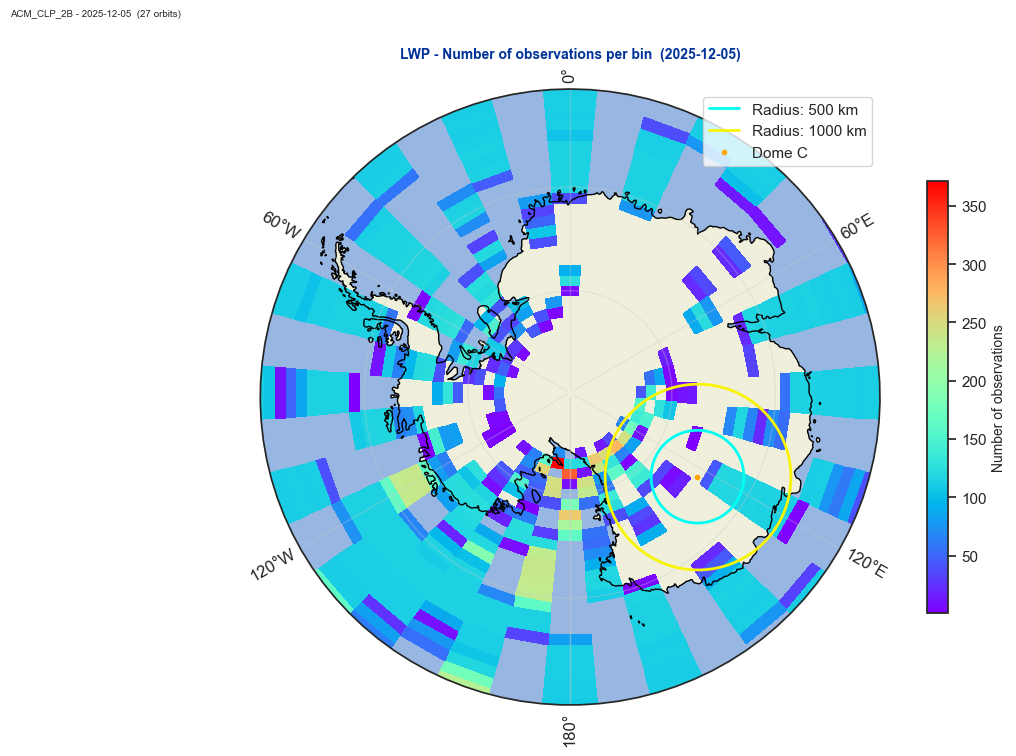

In [15]:
plot_grid_count(grid, day="2025-12-05")

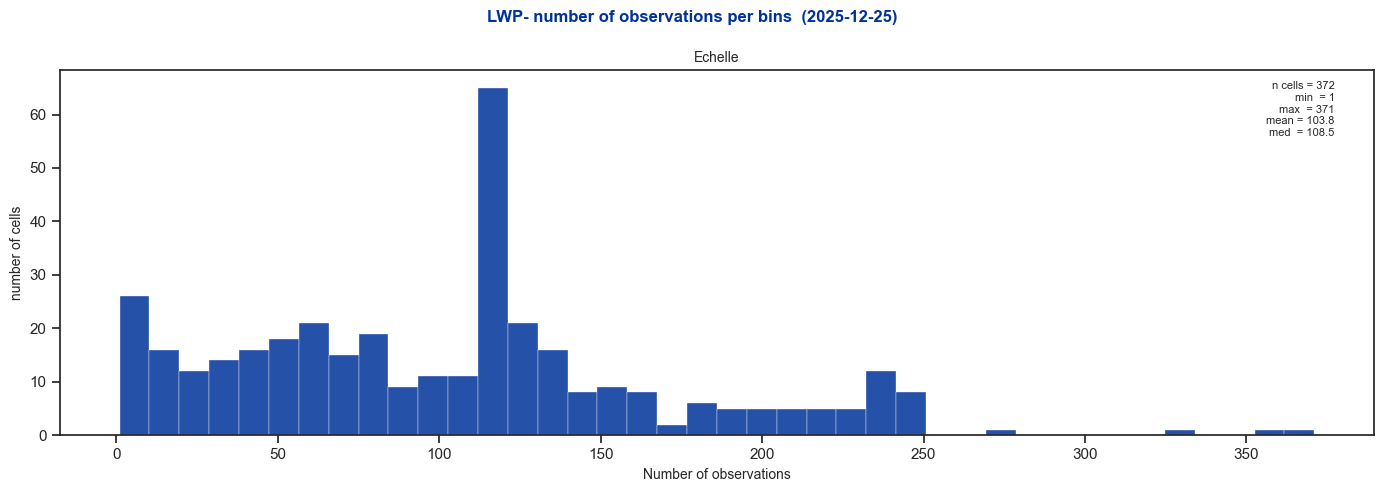

In [12]:
plot_grid_count_histogram(grid, day="2025-12-25")

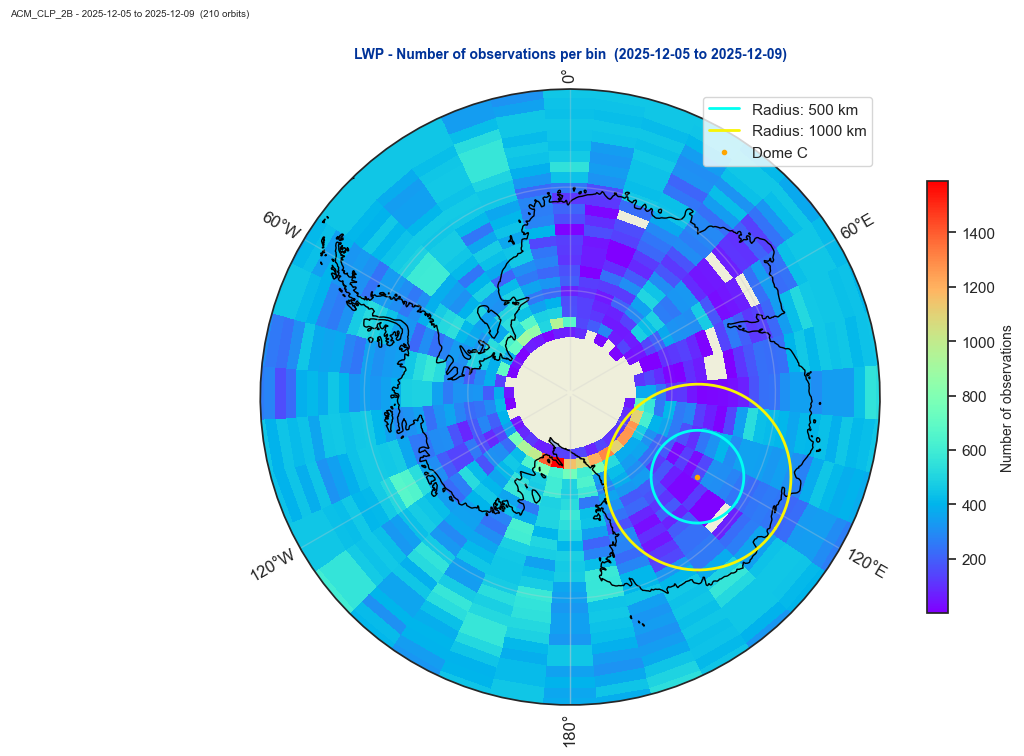

In [7]:
plot_grid_count(grid, d1="2025-12-05", d2="2025-12-09",log_scale=False)

In [ ]:
plot_grid_count(grid, d1="2025-12-05", d2="2025-12-09",log_scale=False)

TypeError: plot_grid_count() got an unexpected keyword argument 'vmin'

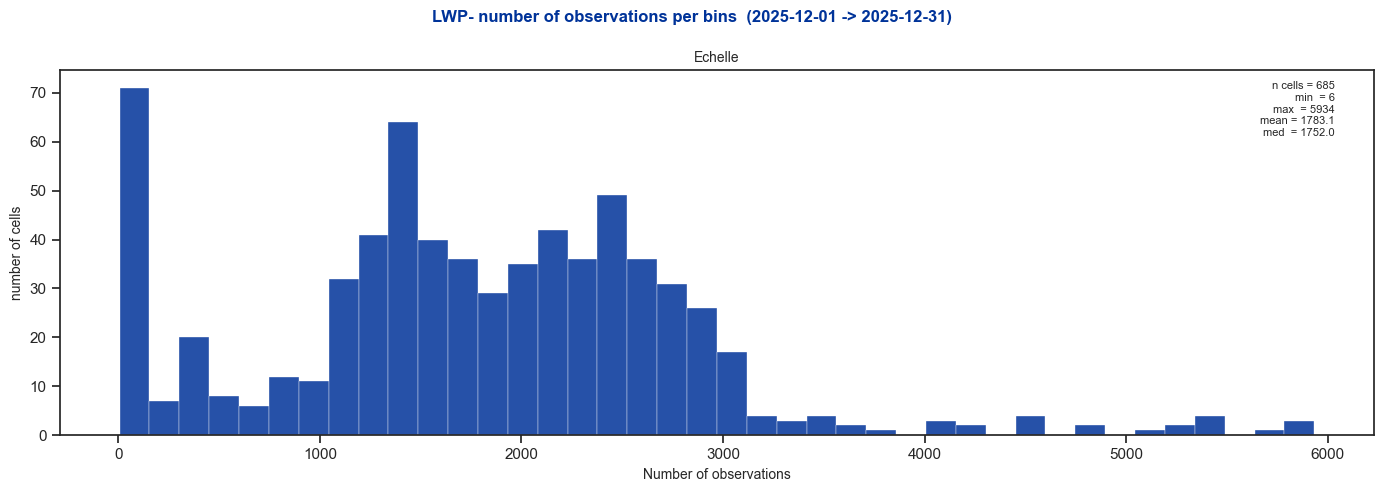

In [11]:
plot_grid_count_histogram(grid, d1="2025-12-01", d2="2025-12-31")

In [8]:
f1 = plot_grid_results(grid, day="2025-12-05")

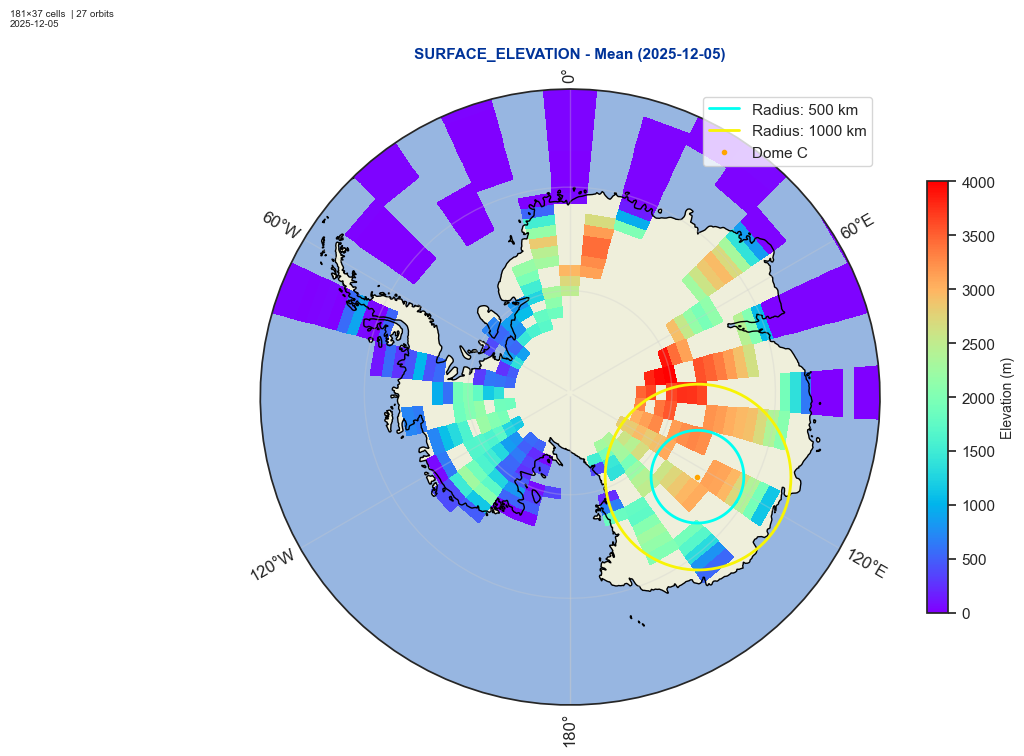

In [9]:
plot_grid_mean(f1, param="surface_elevation", cbar_label="Elevation (m)", vmin=0, vmax=4000)

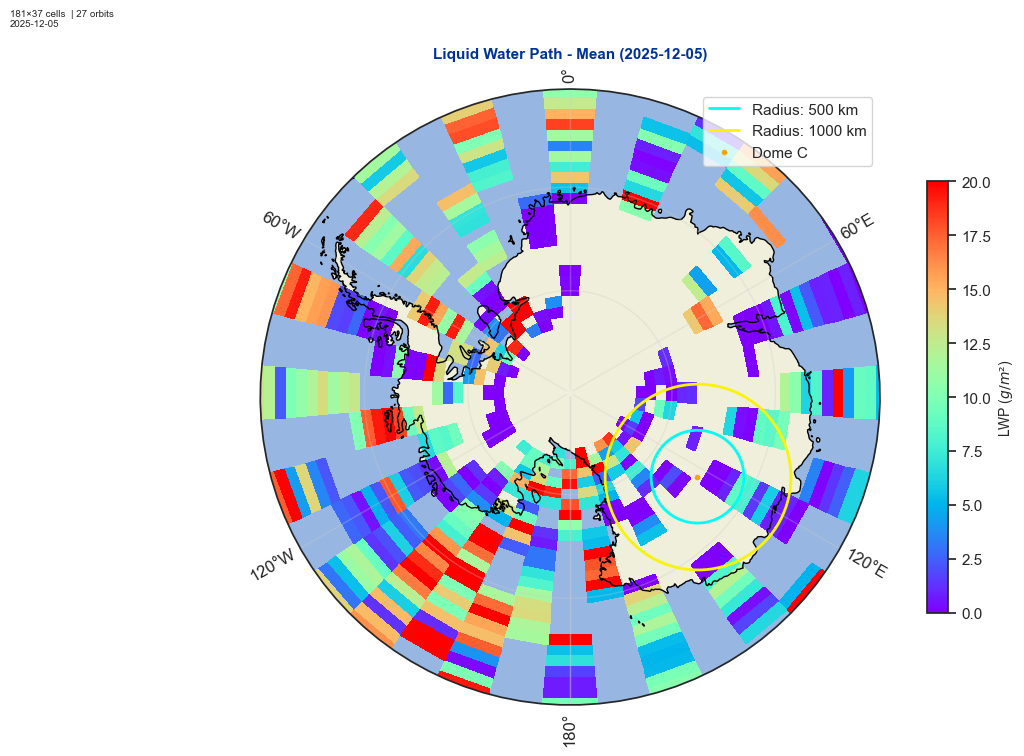

In [19]:
plot_grid_lwp(f1, vmax=20)

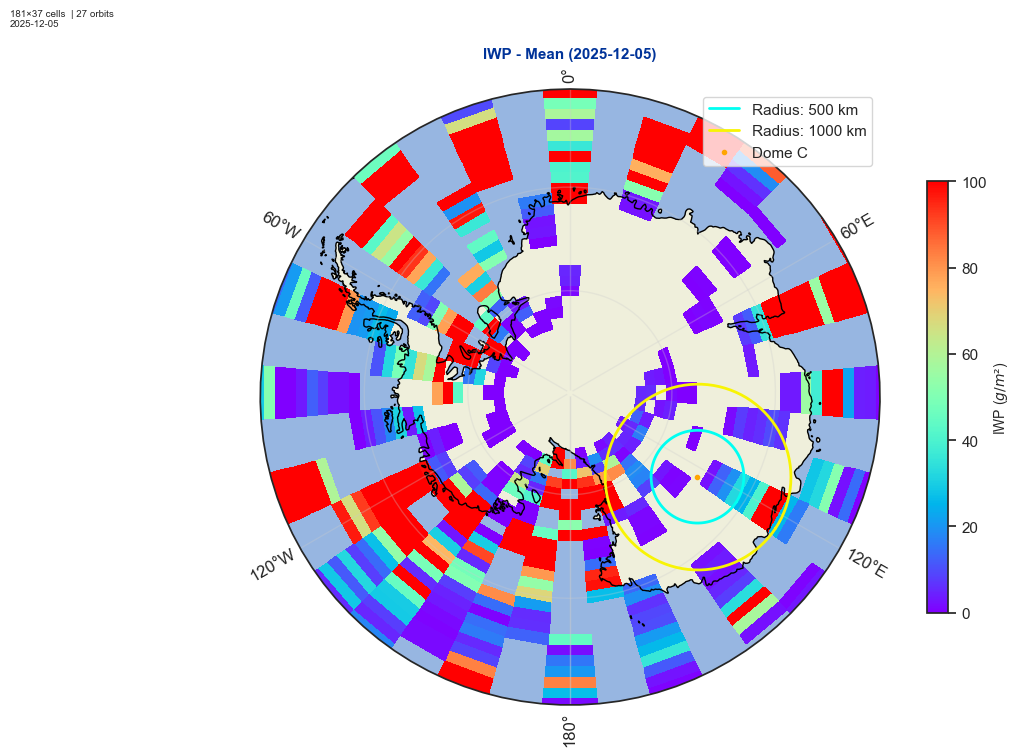

In [20]:
plot_grid_mean(f1, param="iwp", vmax=100)

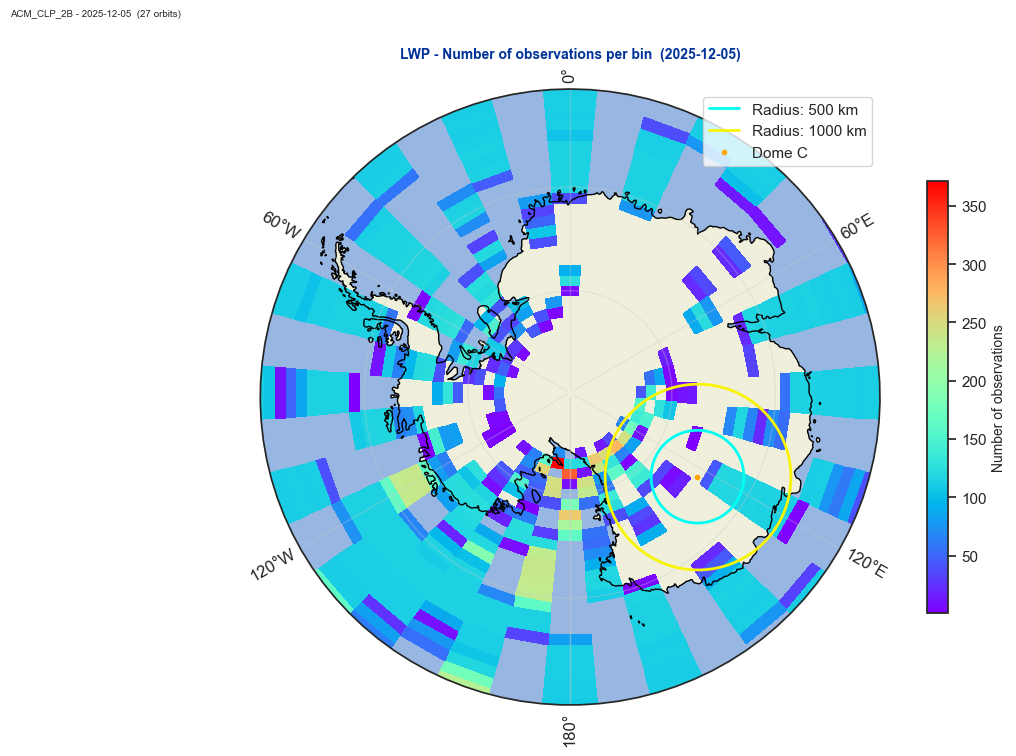

In [27]:
plot_grid_count(grid, day="2025-12-05")

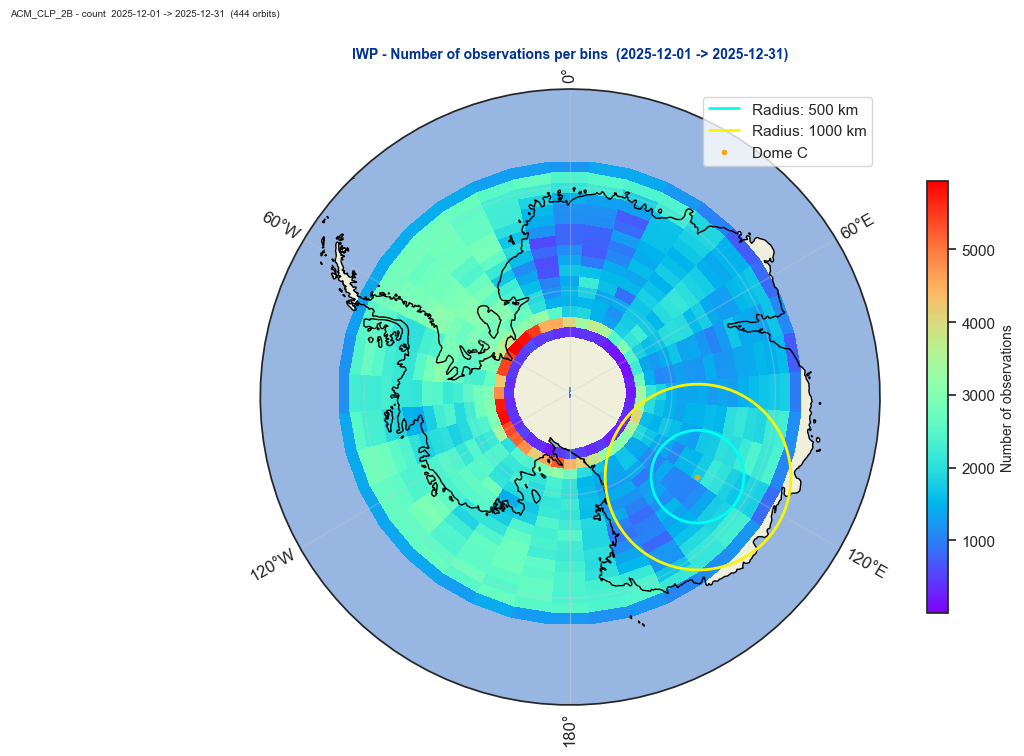

In [21]:
plot_grid_count(grid, d1="2025-12-01", d2="2025-12-31",log_scale=False, param="iwp")


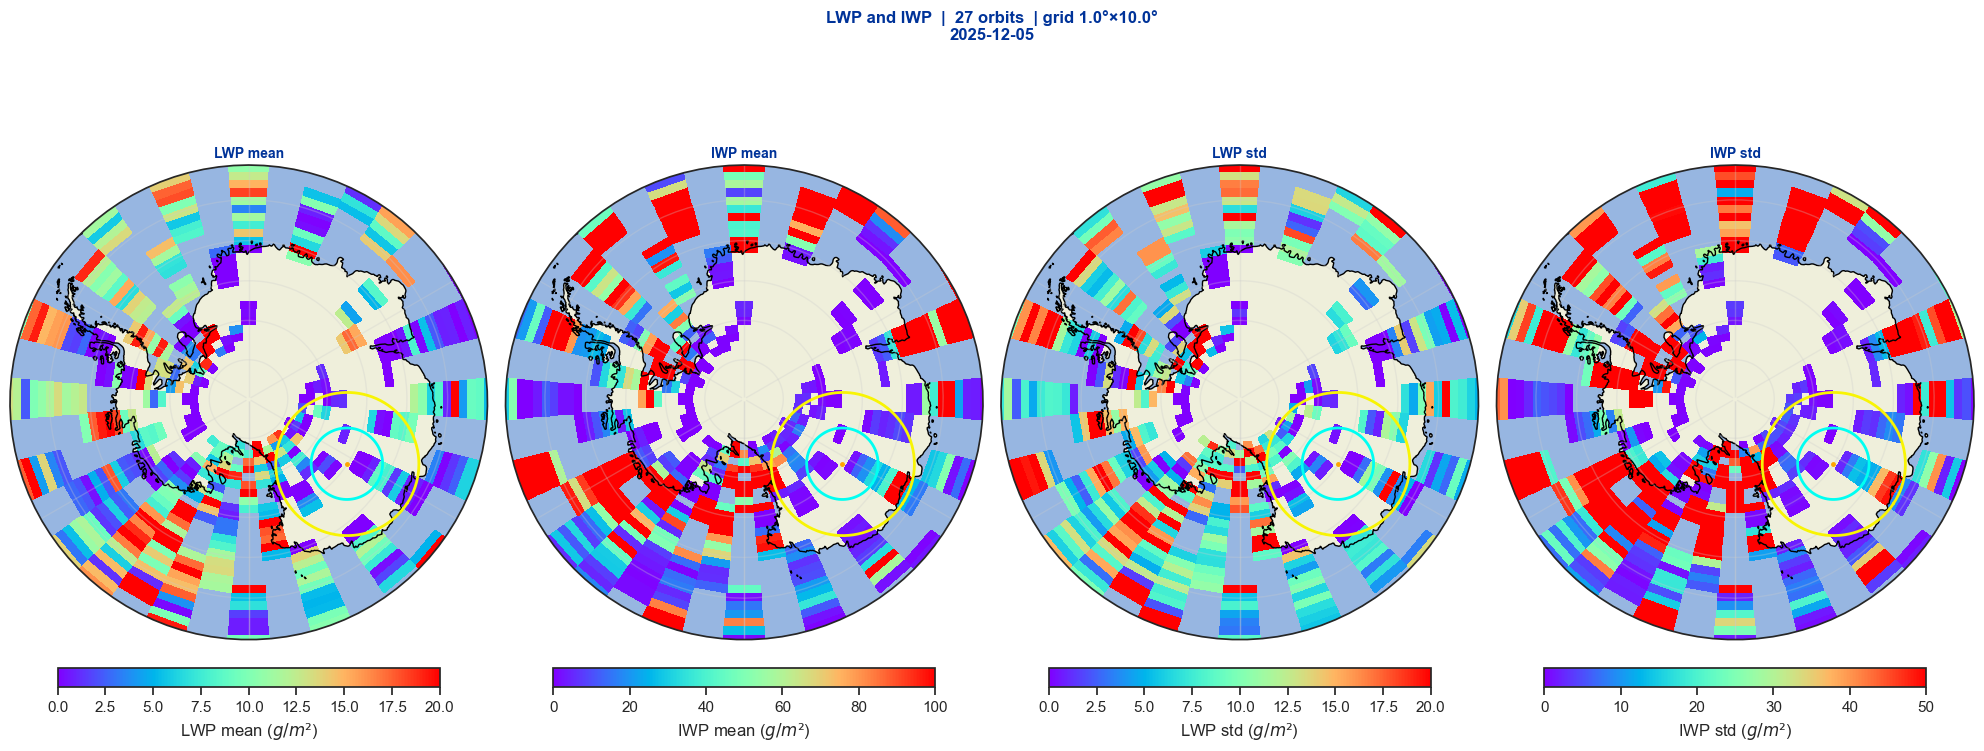

In [21]:
plot_grid_lwp_iwp(f1)

In [10]:
f2 = plot_grid_results(grid, d1="2025-12-06", d2="2025-12-09")

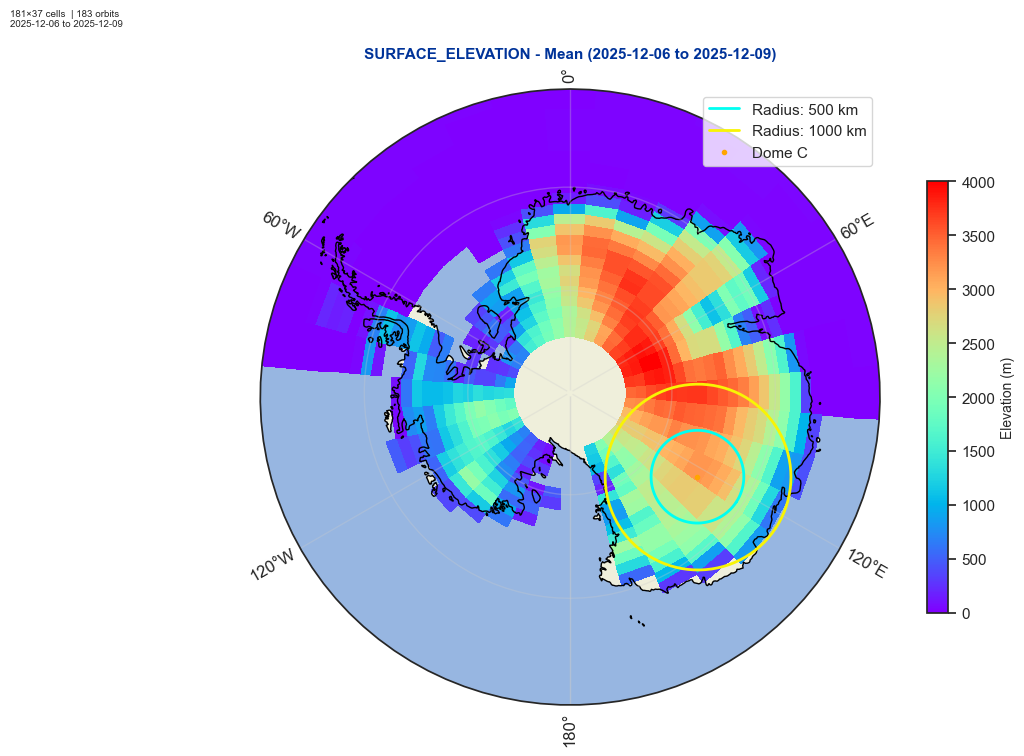

In [12]:
plot_grid_mean(f2, param="surface_elevation", cbar_label="Elevation (m)", vmin=0, vmax=4000)

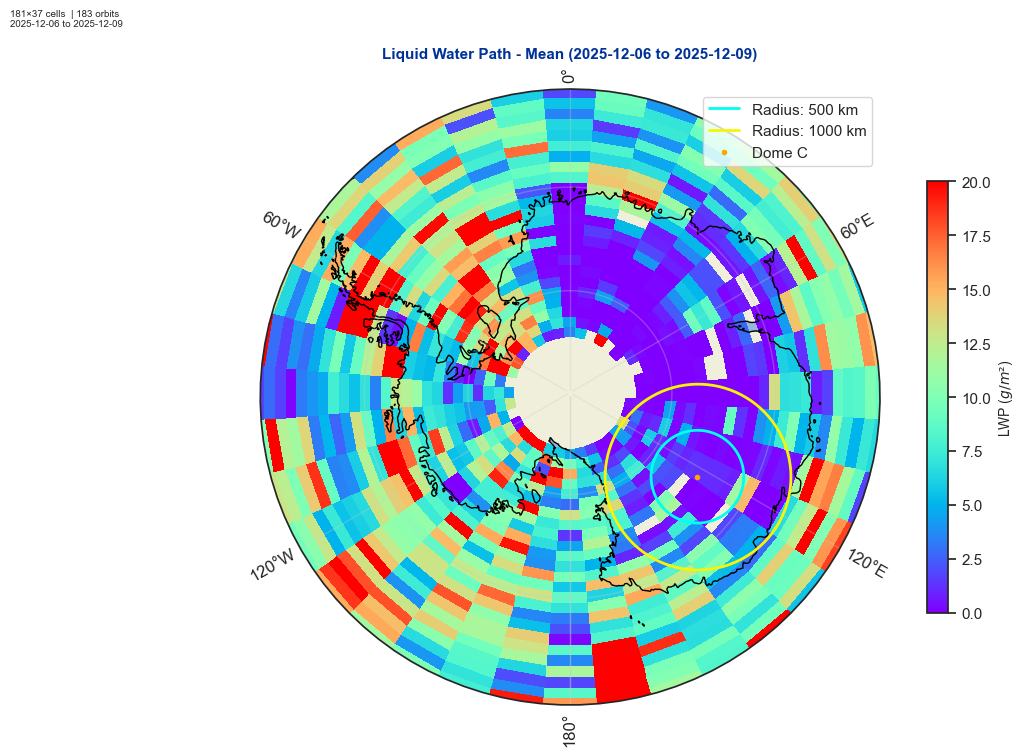

In [23]:
plot_grid_lwp(f2, vmax=20)

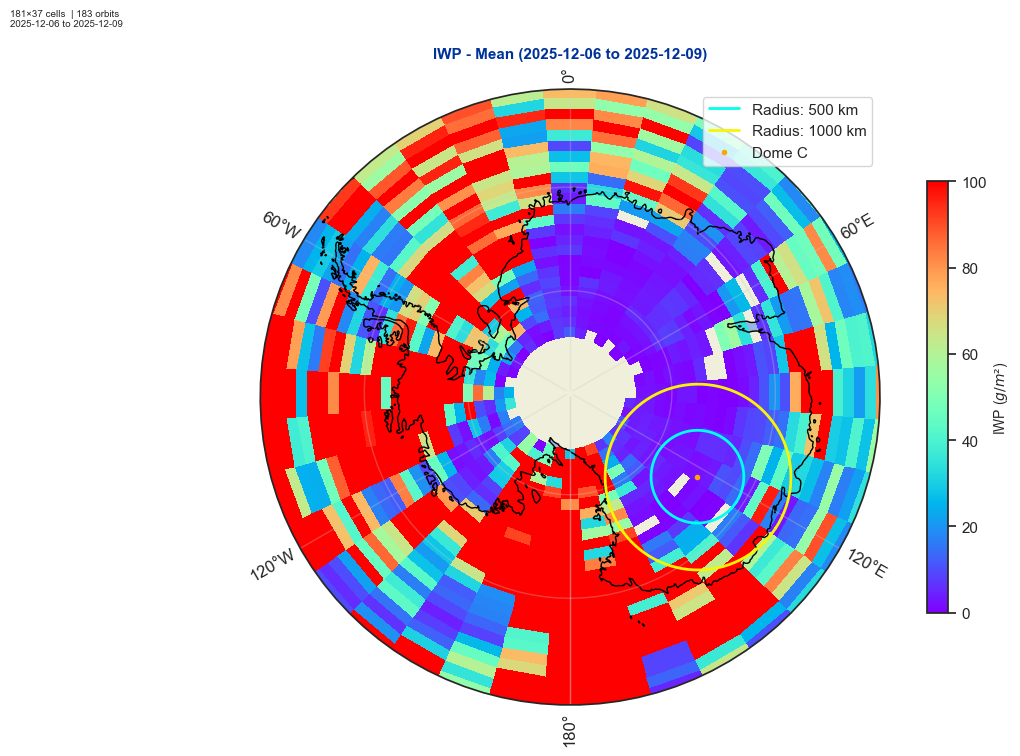

In [11]:
plot_grid_mean(f2, param="iwp", vmax=100)

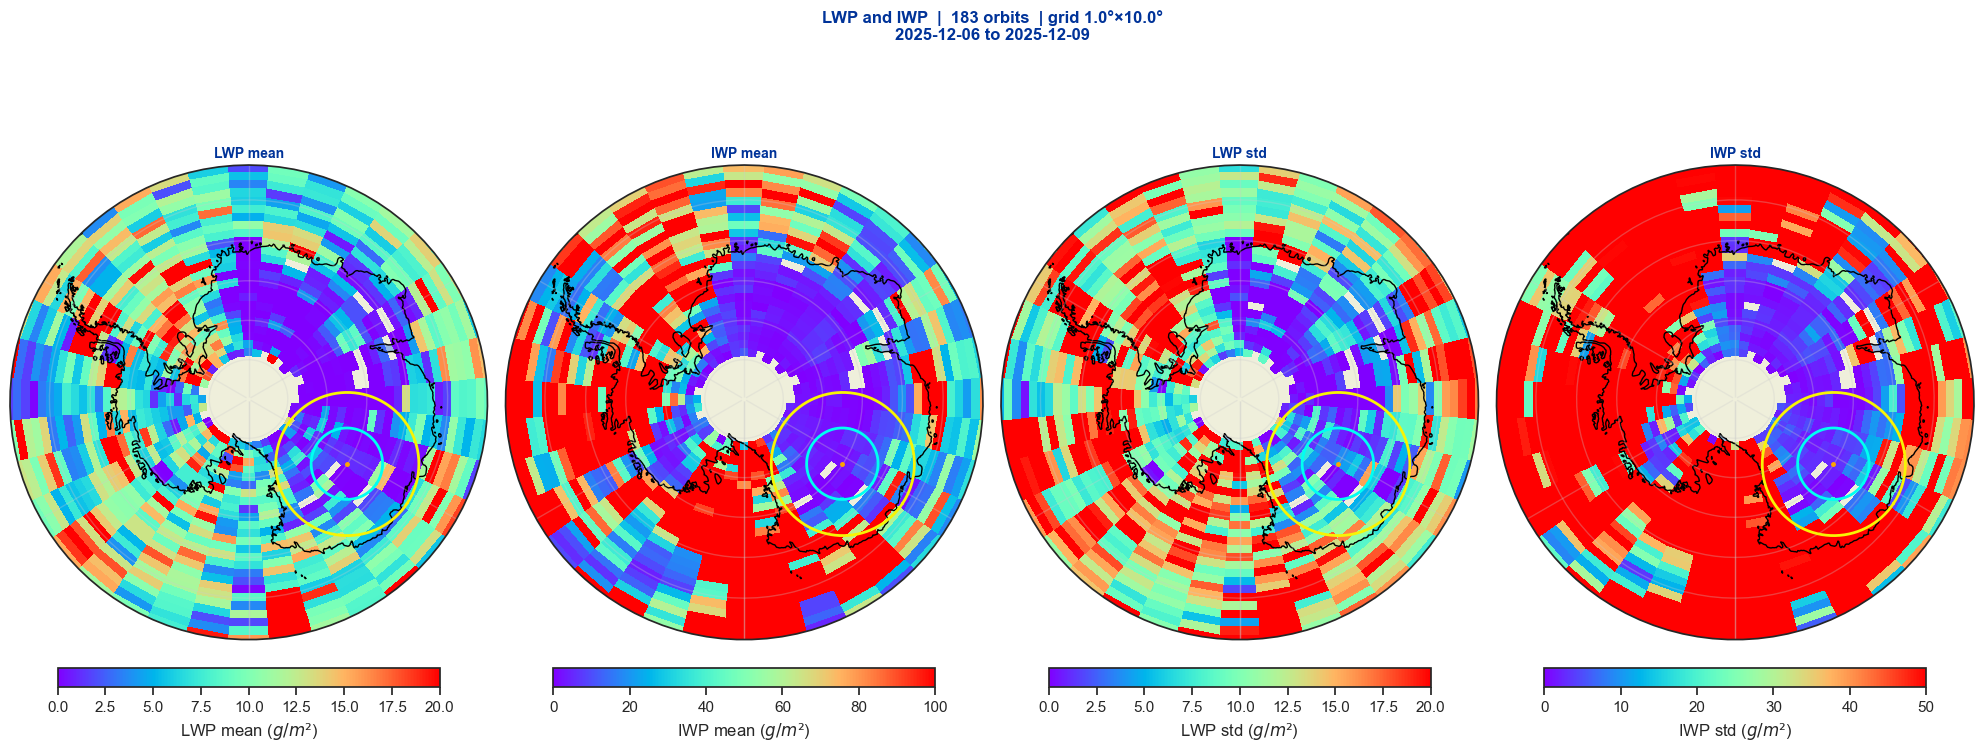

In [26]:
plot_grid_lwp_iwp(f2)

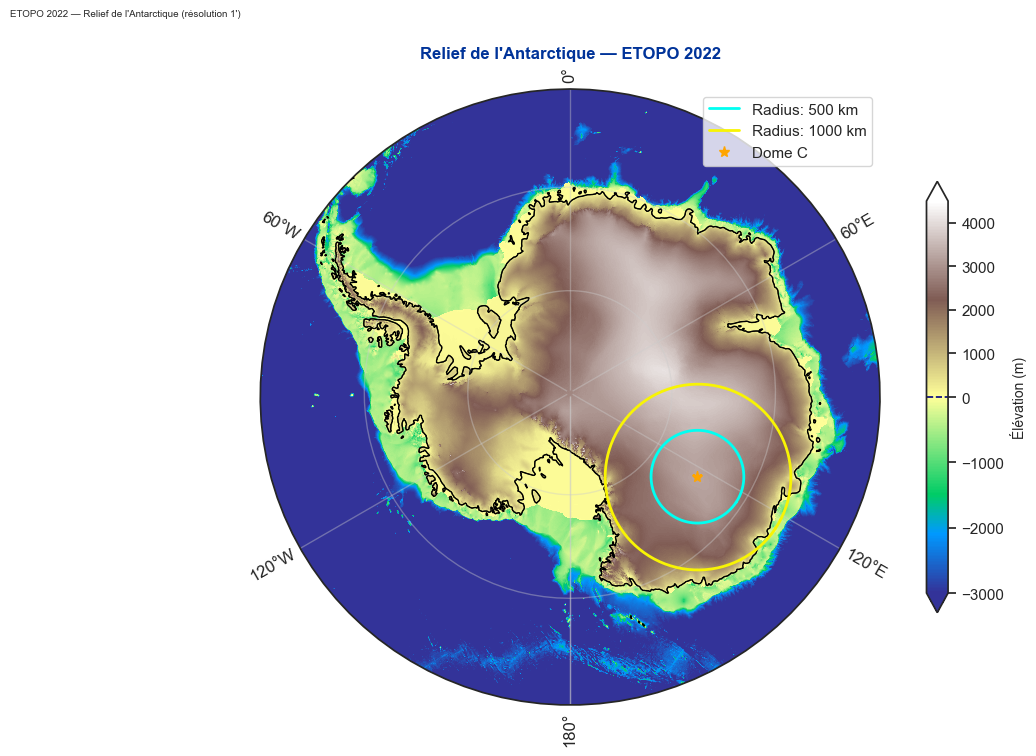

In [4]:
plot_antarctica_relief()

In [3]:
plot_multi_orbit_on_relief(orbites, param="lwp", vmin=0, vmax=40)
plot_multi_orbit_on_relief(orbites, param="iwp", vmin=0, vmax=100)


NameError: name 'orbites' is not defined

In [5]:
plot_antarctica_relief(grid)

TypeError: float() argument must be a string or a real number, not 'GridAccumulator'

### Prendre en compte la fenetre temporelle

### fenetre geographique

### Statistique descriptive(mean and std)

### le nombre d'obs par bins

### Erreurs associées aux obs (pour chaque pixel)